# Treasury Curve Event Study — the findings, illustrated

Charts behind [`findings.md`](findings.md). Everything reads the precomputed
`analysis_*` tables in `data/event_study.db` — no estimation happens here.

To regenerate the data first: `python -m src.ingest.run_ingest --vintage first`
then `python -m src.analytics.run_analysis` (see README).

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

con = sqlite3.connect("../data/event_study.db")

def load(name):
    return pd.read_sql(f"SELECT * FROM {name}", con)

baseline, era, vol = load("analysis_baseline"), load("analysis_era"), load("analysis_event_vol")
gap, cars, obs = load("analysis_gap_trade"), load("analysis_event_study"), load("analysis_observations")

FACTORS = ["level", "slope_2s10s", "slope_5s30s", "curvature"]
LABELS = {"level": "Level (10Y)", "slope_2s10s": "2s10s", "slope_5s30s": "5s30s", "curvature": "Curvature"}
BLUE, DARKBLUE, RED, VIOLET, GRAY = "#2a78d6", "#184f95", "#e34948", "#4a3aa7", "#c3c2b7"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## Data at a glance

Summary statistics for the estimation variables: daily curve-factor changes
(full curve sample) and the releases with their nowcast expectations (study
samples). The surprise standard deviations are the "1σ" units every beta
is quoted in; the GDP extremes are the 2020 COVID quarters.

In [2]:
curve = pd.read_sql("SELECT date, tenor, yield AS y FROM curve", con, parse_dates=["date"]).pivot(index="date", columns="tenor", values="y")
factors = pd.DataFrame({
    "Δ Level (10Y), bps": curve["10Y"].diff(),
    "Δ 2s10s, bps": (curve["10Y"] - curve["2Y"]).diff(),
    "Δ 5s30s, bps": (curve["30Y"] - curve["5Y"]).diff(),
    "Δ Curvature, bps": (2 * curve["10Y"] - curve["2Y"] - curve["30Y"]).diff(),
}) * 100

rel = pd.read_sql("""
    SELECT i.key AS ind, r.ref_period, r.actual, r.consensus
    FROM releases r JOIN indicators i ON i.id = r.indicator_id
    WHERE r.source LIKE '%cleveland_fed' OR r.source = 'gdpnow_track'
""", con, parse_dates=["ref_period"])
rel["surprise"] = rel.actual - rel.consensus

def stats(s, name, rng):
    s = s.dropna()
    return {"Variable": name, "Range": rng, "N": len(s), "Mean": s.mean(),
            "Median": s.median(), "Std dev": s.std(ddof=1), "Min": s.min(), "Max": s.max()}

rng = f"{curve.index.min():%Y-%m} to {curve.index.max():%Y-%m}"
rows = [stats(factors[c], c, rng) for c in factors]
units = {"CPI": "% m/m", "PCE": "% m/m", "GDP": "% q/q saar"}
for ind in ["CPI", "PCE", "GDP"]:
    g = rel[rel.ind == ind]
    rng = f"{g.ref_period.min():%Y-%m} to {g.ref_period.max():%Y-%m}"
    rows += [stats(g.actual, f"{ind} actual ({units[ind]})", rng),
             stats(g.consensus, f"{ind} nowcast ({units[ind]})", rng),
             stats(g.surprise, f"{ind} surprise (pp)", rng)]
pd.DataFrame(rows).round(2)

,Variable,Range,N,Mean,Median,Std dev,Min,Max
0,"Δ Level (10Y), bps",2000-01 to 2026-07,6626,-0.03,0.00,5.79,-51.00,29.00
1,"Δ 2s10s, bps",2000-01 to 2026-07,6626,0.00,0.00,3.90,-28.00,42.00
2,"Δ 5s30s, bps",2000-01 to 2026-07,6626,0.01,0.00,3.84,-24.00,34.00
3,"Δ Curvature, bps",2000-01 to 2026-07,6626,-0.01,0.00,4.15,-53.00,28.00
4,CPI actual (% m/m),2013-08 to 2026-05,153,0.23,0.21,0.29,-0.80,1.32
5,CPI nowcast (% m/m),2013-08 to 2026-05,153,0.22,0.22,0.25,-0.69,1.11
6,CPI surprise (pp),2013-08 to 2026-05,153,0.01,0.01,0.15,-0.37,0.68
7,PCE actual (% m/m),2013-07 to 2026-05,155,0.19,0.17,0.21,-0.47,0.95
8,PCE nowcast (% m/m),2013-07 to 2026-05,155,0.20,0.18,0.20,-0.51,0.94
9,PCE surprise (pp),2013-07 to 2026-05,155,-0.00,-0.01,0.07,-0.21,0.20


## Finding 1 — a hot CPI print bear-flattens the curve, through the long end

Per 1σ of CPI surprise (≈0.15pp), on the release day. The whole curve rises
(level +2.0bp) and 5s30s flattens (−1.3bp); 2s10s and curvature do nothing.

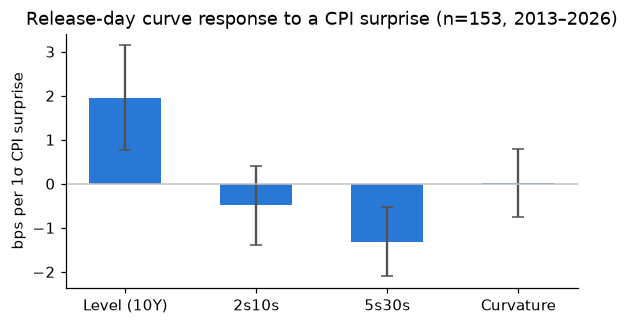

,beta,se,p,r2,n
factor,,,,,
level,1.959,0.603,0.001,0.098,153
slope_2s10s,-0.491,0.462,0.287,0.013,153
slope_5s30s,-1.314,0.404,0.001,0.087,153
curvature,0.017,0.395,0.966,0.000,153


In [3]:
b = baseline.query("indicator == 'CPI' and expectation == 'nowcast'").set_index("factor").loc[FACTORS]

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar([LABELS[f] for f in b.index], b.beta, width=0.55, color=BLUE,
       yerr=[b.beta - b.ci_low, b.ci_high - b.beta], capsize=4, error_kw={"ecolor": "#52514e"})
ax.axhline(0, lw=1, color=GRAY)
ax.set_ylabel("bps per 1σ CPI surprise")
ax.set_title("Release-day curve response to a CPI surprise (n=153, 2013–2026)")
plt.show()

b[["beta", "se", "p", "r2", "n"]].round(3)

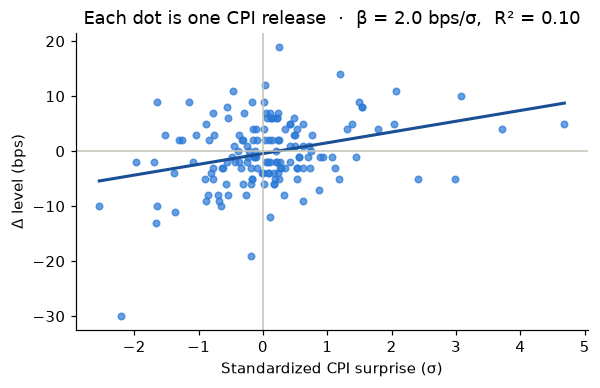

In [4]:
o = obs.query("indicator == 'CPI' and expectation == 'nowcast'")
row = b.loc["level"]

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.scatter(o.surprise_z, o.delta_level, s=18, color=BLUE, alpha=0.7)
xs = pd.Series([o.surprise_z.min(), o.surprise_z.max()])
ax.plot(xs, row.alpha + row.beta * xs, color=DARKBLUE, lw=2)
ax.axhline(0, lw=1, color=GRAY); ax.axvline(0, lw=1, color=GRAY)
ax.set_xlabel("Standardized CPI surprise (σ)"); ax.set_ylabel("Δ level (bps)")
ax.set_title(f"Each dot is one CPI release  ·  β = {row.beta:.1f} bps/σ,  R² = {row.r2:.2f}")
plt.show()

### …and the effect lives in the inflation era

Split at 2021-01-01: before, nothing significant; after, the level beta is
+2.3bp and 5s30s −1.7bp with R² around 15%. Sizing should use the post-2021
numbers; the pre-2021 rows warn the beta can fade to zero.

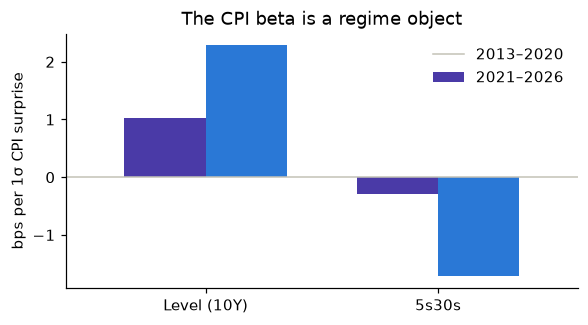

,era,factor,n,beta,p,r2
0,pre_2021,level,88,1.033,0.139,0.023
2,pre_2021,slope_5s30s,88,-0.284,0.590,0.004
12,post_2021,level,65,2.283,0.004,0.140
14,post_2021,slope_5s30s,65,-1.720,0.001,0.154


In [5]:
e = era.query("indicator == 'CPI' and factor in ['level', 'slope_5s30s']")
piv = e.pivot(index="factor", columns="era", values="beta").loc[["level", "slope_5s30s"], ["pre_2021", "post_2021"]]

ax = piv.rename(index=LABELS).plot.bar(color=[VIOLET, BLUE], width=0.7, rot=0, figsize=(6, 3))
ax.axhline(0, lw=1, color=GRAY)
ax.set_ylabel("bps per 1σ CPI surprise"); ax.set_xlabel(None)
ax.legend(["2013–2020", "2021–2026"], frameon=False)
ax.set_title("The CPI beta is a regime object")
plt.show()

e[["era", "factor", "n", "beta", "p", "r2"]].round(3)

## Finding 2 — only CPI trades like a real event

Volatility of the daily 10Y change on release days vs ordinary days. Post-2021
CPI days run ~1.4× normal; GDP days are ordinary; PCE days are *quieter* than
ordinary. The calendar premium belongs on CPI day.

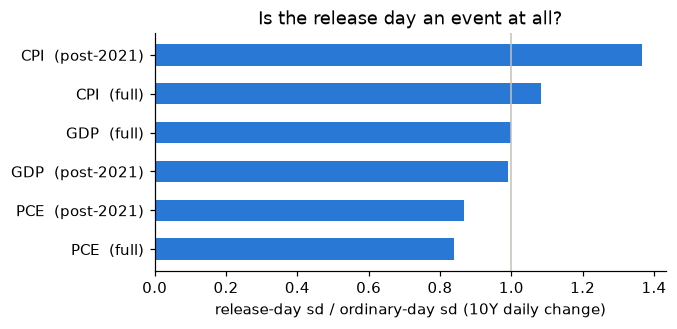

,indicator,window,n_event,sd_event,sd_control,vol_ratio
8,PCE,full,153,4.86,5.79,0.84
20,PCE,post_2021,65,5.18,5.96,0.87
16,GDP,post_2021,22,5.91,5.96,0.99
4,GDP,full,59,5.79,5.79,1.00
0,CPI,full,153,6.27,5.79,1.08
12,CPI,post_2021,65,8.14,5.96,1.37


In [6]:
v = vol.query("factor == 'level'").copy()
v["label"] = v.indicator + "  (" + v.window.str.replace("_", "-") + ")"
v = v.sort_values("vol_ratio")

fig, ax = plt.subplots(figsize=(6, 2.8))
ax.barh(v.label, v.vol_ratio, color=BLUE, height=0.55)
ax.axvline(1, lw=1, color=GRAY)
ax.set_xlabel("release-day sd / ordinary-day sd (10Y daily change)")
ax.set_title("Is the release day an event at all?")
plt.show()

v[["indicator", "window", "n_event", "sd_event", "sd_control", "vol_ratio"]].round(2)

## Finding 3 — the public nowcast is already in the price

Rule: the day before a release, position in the direction of
(public nowcast − previous print); exit at the release-day close. The signal
is fully public before the print. It earns nothing: hit rates at or below a
coin flip, gross P&L ≈ zero. What is tradable is only the residual surprise
at 8:30:00.

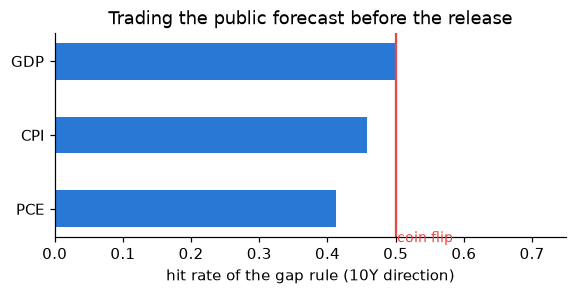

,indicator,factor,n,hit_rate,mean_pnl,t_pnl,gamma_p
0,CPI,level,153,0.458,-0.601,-1.191,0.291
1,CPI,slope_2s10s,153,0.425,-0.294,-0.845,0.272
2,CPI,slope_5s30s,153,0.497,0.098,0.272,0.689
3,CPI,curvature,153,0.425,-0.340,-1.050,0.558
4,GDP,level,58,0.500,-0.172,-0.249,0.616
5,GDP,slope_2s10s,58,0.483,-0.276,-0.550,0.348
6,GDP,slope_5s30s,58,0.397,-0.552,-1.220,0.211
7,GDP,curvature,58,0.517,0.017,0.034,0.408
8,PCE,level,155,0.413,0.006,0.017,0.982
9,PCE,slope_2s10s,155,0.432,-0.206,-0.818,0.148


In [7]:
g = gap.query("factor == 'level'").sort_values("hit_rate")

fig, ax = plt.subplots(figsize=(6, 2.4))
ax.barh(g.indicator, g.hit_rate, color=BLUE, height=0.5)
ax.axvline(0.5, lw=1.5, color=RED)
ax.text(0.502, -0.45, "coin flip", color=RED, fontsize=9)
ax.set_xlim(0, 0.75); ax.set_xlabel("hit rate of the gap rule (10Y direction)")
ax.set_title("Trading the public forecast before the release")
plt.show()

gap[["indicator", "factor", "n", "hit_rate", "mean_pnl", "t_pnl", "gamma_p"]].round(3)

### The response is on the release day, with no drift to chase

Cumulative abnormal change in the 10Y level around the largest CPI surprises
(top/bottom decile, 16 events per tail). The jump happens at day 0; the paths
before and after stay within noise.

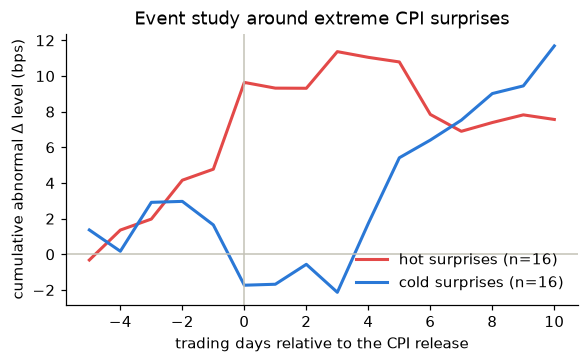

In [8]:
c = cars.query("indicator == 'CPI' and factor == 'level'")

fig, ax = plt.subplots(figsize=(6, 3.2))
for grp, color in [("hot", RED), ("cold", BLUE)]:
    p = c[c.group == grp].sort_values("tau")
    ax.plot(p.tau, p.car, color=color, lw=2, label=f"{grp} surprises (n={int(p.n_events.iloc[0])})")
ax.axvline(0, lw=1, color=GRAY); ax.axhline(0, lw=1, color=GRAY)
ax.set_xlabel("trading days relative to the CPI release")
ax.set_ylabel("cumulative abnormal Δ level (bps)")
ax.legend(frameon=False)
ax.set_title("Event study around extreme CPI surprises")
plt.show()

---
**Takeaways** (full treatment, methodology and limitations in
[`findings.md`](findings.md)):

1. A 1σ CPI surprise lifts the curve ~2.3bp and flattens 5s30s ~1.7bp, but only
   since 2021. Express a CPI view in the long-end slope or outright duration,
   not 2s10s, and size it by regime.
2. CPI is the only one of these releases the curve prices as an event
   (1.4× vol post-2021); GDP days are ordinary and PCE days are quiet.
3. Public nowcasts are priced by the prior close; only the 8:30 residual
   surprise is tradable, and that is a speed game.

Every number here is cross-checked against the paper draft by
`python -m src.analytics.verify_paper`.